# Bobs Visualisierung von Vektorrepräsentationen
In diesem Programm werden einfache 2D-Vektoren (z. B. Word Embeddings)
visualisiert und deren Ähnlichkeiten untersucht.

**Kernideen**:
- Darstellung von Vektoren im 2D-Raum
- Euklidische Distanz (Abstand)
- Kosinus-Distanz (Winkel)
- Visualisierung der Distanzen als Heatmap


## Imports

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

## Funktionen zur Visualisierung
Diese Funktionen dienen zur Visualisierung der Ergebnisse

In [2]:
def show_vectors(words, vectors):
    
    """
    Visualisiert Vektoren als Pfeile vom Ursprung.

    Parameter:
    - words: Liste von Wörtern
    - vectors: Liste von 2D-Vektoren
    """
    
    plt.figure(figsize=(6, 4))

    # Define colors for each word
    colors = ["green", "red", "blue", "magenta", "black", "cyan", "gold", "orange"]

    # Plot vectors from origin to each point
    for i, word in enumerate(words):
        x, y = vectors[i]
        color = colors[i % len(colors)]
        plt.arrow( 0, 0, x, y, head_width=0.04, head_length=0.04, fc=color, ec=color, alpha=0.7, length_includes_head=True)

        # Add dot at the end of the vector and include in legend
        label = f"{word}"
        plt.scatter(x, y, color=color, s=70, marker="o", label=label)

    plt.title("2D-Vektorrepräsentationen", fontsize=13)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.axis("equal")  # Equal aspect ratio to preserve vector angles
    plt.tight_layout()
    plt.show()

In [3]:
def plot_heatmap(distance_matrix, words, title):

    """
    Visualisiert eine Distanzmatrix als Heatmap.

    Parameter:
    - distance_matrix: nxn Matrix mit Distanzen
    - words: Labels für Achsen
    - title: Titel der Darstellung
    """
    
    distance_matrix = np.array(distance_matrix)

    plt.figure(figsize=(4, 3))

    # Farbskala
    im = plt.imshow(distance_matrix, cmap="coolwarm", vmin=0, vmax=np.max(distance_matrix))
    plt.colorbar(im)
    
    # Titel
    plt.title(title + "\nHeatmap", fontsize=10)
    
    # Achsenbeschriftung
    plt.xticks(range(len(words)), words,fontsize=9, rotation=45)
    plt.yticks(range(len(words)), words, fontsize=9)

    # Werte in Zellen anzeigen
    for i in range(distance_matrix.shape[0]):
        for j in range(distance_matrix.shape[1]):
            plt.text(j, i, f"{distance_matrix[i, j]:.2f}",
                     ha="center", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

## 1. Beispiel-Daten

In [4]:
words = ["Wandern", "Klettern", "Backen"]

In [5]:
w = [1.0, 0.8]
k = [0.7, 0.9]
b = [0.0, 0.1]

In [6]:
vectors = [w, k, b]

## 2. Visualisierung

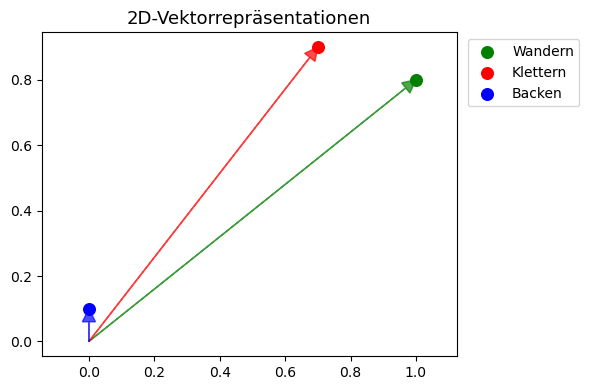

In [7]:
show_vectors(words, vectors)

## Ähnlichkeit von Vektoren

### Ähnlichkeit von Vektoren I: Euklidische Distanz

##### Beispiel: Berechne euklidische Distanz zwischen "Wandern" und "Klettern"'

In [9]:
from scipy.spatial.distance import euclidean

dist = euclidean(np.array(w), np.array(k))
dist

0.31622776601683794

##### Berechnung der Distanzmatrix

In [10]:
def calculate_pairwise_euclidean_matrix(vectors):

    """
    Berechnet alle paarweisen euklidischen Distanzen.
    """
    
    n = len(vectors)
    
    # leere nxn Matrix
    distances = np.zeros((n, n))

    # Berechnen der Distanzen
    for i in range(n):
        for j in range(n):
            distances[i, j] = euclidean(np.array(vectors[i]), np.array(vectors[j]))
    
    return distances

In [11]:
eucl_dist_matrix = calculate_pairwise_euclidean_matrix(vectors)

##### Visualisierung als Heatmap

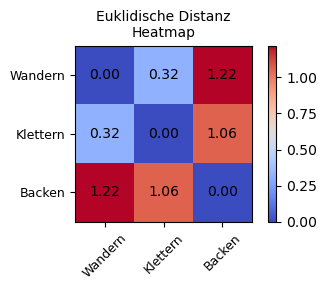

In [12]:
plot_heatmap(eucl_dist_matrix, words, "Euklidische Distanz")

### Ähnlichkeit von Vektoren II: Kosinus-Distanz

##### Beispiel: Berechne Kosinus Ähnlichkeit zwischen "Wandern" und "Klettern"

In [13]:
from scipy.spatial.distance import cosine

sim = cosine(np.array(w), np.array(k))
sim

#cos_dist = cosine(v1, v2)

0.02748850308478612

##### Berechnung der Distanzmatrix

In [14]:
def calculate_pairwise_cosine_matrix(vectors):

    """
    Berechnet alle paarweisen Kosinus-Distanzen.
    """
    
    n = len(vectors)
    
    # leere nxn Matrix
    distances = np.zeros((n, n))

    # Berechnen der Distanzen
    for i in range(n):
        for j in range(n):
            distances[i, j] = cosine(np.array(vectors[i]), np.array(vectors[j]))
    
    return distances

In [15]:
cosine_matrix = calculate_pairwise_cosine_matrix(vectors)
cosine_matrix

array([[0.        , 0.0274885 , 0.37530495],
       [0.0274885 , 0.        , 0.21064778],
       [0.37530495, 0.21064778, 0.        ]])

##### Visualisierung als Heatmap

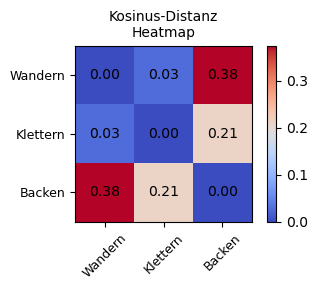

In [16]:
plot_heatmap(cosine_matrix, words, "Kosinus-Distanz")